In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from google.colab import drive
from scipy.stats import norm
from matplotlib.patches import Ellipse

In [2]:
drive.mount('/content/drive')
workpath = '/content/drive/MyDrive'

Mounted at /content/drive


In [3]:
device = 'cuda'
device = torch.device("cuda:0" if (device == 'cuda') and torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [4]:
class CudaDataset(Dataset):
  def __init__(self, dataset, device, transform = None):
    self.dataset = dataset
    self.cuda_x = []
    self.cuda_y = []
    self.device = device
    self.transform = transform

    for x, y in tqdm(self.dataset, desc = "Moving to GPU"):
      self.cuda_x.append(x.to(self.device))
      self.cuda_y.append(torch.tensor(y, device=self.device))

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    if self.transform is None:
      x = self.cuda_x[idx]
    else:
      x = self.transform(self.cuda_x[idx])
    return x, self.cuda_y[idx]

def split_dataset(dataset, split_share=0.1):
  """
  Devuelve dos subconjuntos del dataset. split_share define cuántos ejemplos irán al
  primer subconjunto. El resto irán al segundo.
  """
  mask_indices_to_first_subset = torch.rand(len(dataset))<=split_share
  indices_first_subset = [i for i, (_, _) in enumerate(dataset) if mask_indices_to_first_subset[i]]
  indices_second_subset = [i for i, (_, _) in enumerate(dataset) if not mask_indices_to_first_subset[i]]

  first_subset = torch.utils.data.Subset(dataset, indices_first_subset)
  second_subset = torch.utils.data.Subset(dataset, indices_second_subset)

  return first_subset, second_subset

def filter_dataset(dataset, chosen_labels):
  """
  Devuelve un subconjunto del dataset que solo contiene las etiquetas especificadas.
  """
  indices = [i for i, (_, y) in enumerate(dataset) if y in chosen_labels]
  subset = torch.utils.data.Subset(dataset, indices)
  return subset

In [5]:
train_dataset = datasets.MNIST(root = workpath, train = True, download = True, transform = transforms.ToTensor())
test_dataset = datasets.MNIST(root = workpath, train = False, download = True, transform = transforms.ToTensor())

# Filtrar para quedarnos solo con las clases de 0 a 5 en entrenamiento
training_labels = [0, 1, 2, 3, 4, 5]
train_dataset = filter_dataset(train_dataset, training_labels)

if not str(device) == "cpu":
  train_dataset = CudaDataset(train_dataset, device)
  test_dataset = CudaDataset(test_dataset, device)

val_dataset, train_dataset = split_dataset(train_dataset)

Moving to GPU: 100%|██████████| 10000/10000 [00:02<00:00, 4887.08it/s]


In [6]:
print(f"Número de ejemplos en entrenamiento: {len(train_dataset)}")
print(f"Número de ejemplos en validación: {len(val_dataset)}")
print(f"Número de ejemplos en test: {len(test_dataset)}")

Número de ejemplos en entrenamiento: 32431
Número de ejemplos en validación: 3586
Número de ejemplos en test: 10000


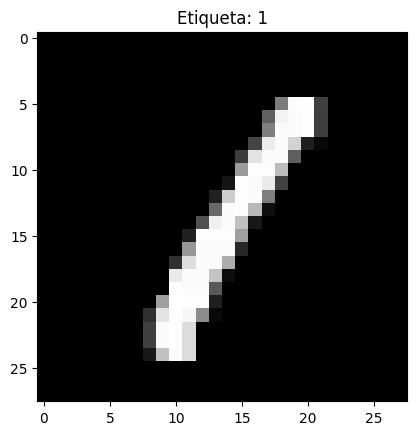

torch.Size([1, 28, 28])


In [7]:
image, label = train_dataset[3]
plt.imshow(image.permute(1, 2, 0).cpu(), cmap = 'gray')
plt.title(f"Etiqueta: {label}")
plt.show()
print(image.shape)

In [8]:
class Early_Stop():
  def __init__(self, patience=5, delta=0):
    self.patience = patience
    self.delta = delta
    self.best_val_loss = None
    self.no_val_improvement_times = 0
    self.stop = False

  def check_stop(self, val_loss):
    if self.best_val_loss is None or (val_loss + self.delta) < self.best_val_loss:
      self.best_val_loss = val_loss
      self.no_val_improvement_times = 0
    else:
      self.no_val_improvement_times += 1
      self.stop = self.no_val_improvement_times >= self.patience

In [9]:
def learning_loop(train_dataloader, val_dataloader, model, epochs, loss_fn_cls, loss_fn_rec, learning_rate, optimizer, validation_freq, early_stop):
  epoch_loss_list = []
  val_loss_list = []

  opt = optimizer(model.parameters(), lr=learning_rate)

  with tqdm(range(epochs), desc="Epoch:") as pbar:
    for epoch in pbar:
      steps_loss_list = []
      for x_true, y_true in train_dataloader:
        y_pred, _, x_rec = model(x_true)                           # Forward
        opt.zero_grad()

        loss_classif = loss_fn_cls(y_pred, y_true)
        loss_rec = loss_fn_rec(x_rec, x_true)
        loss = loss_classif + loss_rec
        #loss = loss_classif + (10.0 * loss_rec) # Dándole más importancia a MSE
        loss.backward()                                     # Backward
        steps_loss_list.append(loss.clone().detach())
        opt.step()

      train_loss = torch.tensor(steps_loss_list).mean()
      epoch_loss_list.append(train_loss.cpu())
      pbar.set_postfix(loss=f"{train_loss:.4f}")

      if epoch % validation_freq == 0:
        val_step_loss_list = []
        #val_correct_answers = 0

        with torch.no_grad():
          for x_val_true, y_val_true in val_dataloader:
            y_val_pred, _, x_val_rec = model(x_val_true)

            loss_val_cls = loss_fn_cls(y_val_pred, y_val_true)
            loss_val_rec = loss_fn_rec(x_val_rec, x_val_true)
            loss_val = loss_val_cls + loss_val_rec
            val_step_loss_list.append(loss_val)

          val_loss = torch.tensor(val_step_loss_list).mean()
          val_loss_list.append(val_loss.cpu())
          #pbar.set_postfix(val_loss=f"{val_loss:.4f}")

        early_stop.check_stop(val_loss)
        if early_stop.stop:
          print(f"\nEarly Stop en la época {epoch}.")
          break

  return model, epoch_loss_list, val_loss_list

In [10]:
def covariance_ellipse(points, num_of_stds=2.0, **kwargs):
    center = np.mean(points, axis=0) # Calculate center.
    cov = np.cov(points, rowvar=False) # Calculate covariance matrix.

    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])) # Angle of rotation.
    width, height = 2 * num_of_stds * np.sqrt(eigenvalues)
    ellipse = Ellipse(xy=center, width=width, height=height, angle=angle, **kwargs)

    return ellipse

## Experimento con sigmoide:

In [11]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dims=2, num_classes=6):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, latent_dims),
            nn.Sigmoid()
        )

        self.classifier = nn.Linear(latent_dims, num_classes)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dims, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_space = self.encoder(x)
        predict = self.classifier(latent_space)
        reconstructed = self.decoder(latent_space)
        reconstructed = reconstructed.view(-1, 1, 28, 28)

        return predict, latent_space, reconstructed

Epoch::  16%|█▌        | 310/2000 [02:24<13:07,  2.15it/s, loss=0.0496]


Early Stop en la época 310.


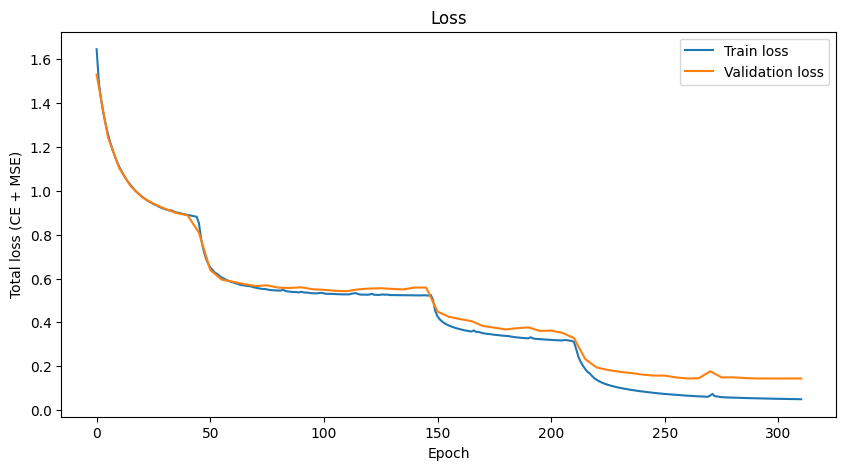

In [12]:
batch_size = 256
learning_rate = 1e-3
epochs = 2000
validation_freq = 5
patience = 10
delta = 0.001

loss_fn_cls = torch.nn.CrossEntropyLoss()
loss_fn_rec = torch.nn.MSELoss()
optimizer = torch.optim.Adam

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

model = Autoencoder(latent_dims=2).to(device)
early_stop = Early_Stop(patience=patience, delta=delta)

model, train_loss_list, val_loss_list = learning_loop(
    train_loader, val_loader, model, epochs, loss_fn_cls, loss_fn_rec, learning_rate, optimizer, validation_freq, early_stop
)

plt.figure(figsize=(10, 5))
plt.plot(train_loss_list, label='Train loss')
plt.plot(np.arange(0, len(train_loss_list), validation_freq), val_loss_list, label='Validation loss')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Total loss (CE + MSE)')
plt.show()

In [13]:
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_step_loss_list = []
test_correct_answers = 0
test_set_size = 0

with torch.no_grad():
    for x_true, y_true in test_loader:

        y_pred, latent_space, x_rec = model(x_true)
        preds = torch.argmax(y_pred, dim=-1)
        correct_answers = torch.sum(preds == y_true)
        test_correct_answers += correct_answers.item()
        test_set_size += y_true.numel()

        mask = y_true <= 5
        if mask.any(): # Si hay al menos un número del 0 al 5 en este batch.
            loss_test_cls = loss_fn_cls(y_pred[mask], y_true[mask])
            loss_test_rec = loss_fn_rec(x_rec[mask], x_true[mask])
            total_loss = loss_test_cls + loss_test_rec
            test_step_loss_list.append(total_loss.item())

final_test_loss = np.mean(test_step_loss_list)
final_test_acc = test_correct_answers / float(test_set_size)

print(f"Test dataset loss (classes 0-5): {final_test_loss:.6f}")
print(f"Test dataset accuracy (classes 0-5): {final_test_acc:.2%}")

Test dataset loss (classes 0-5): 0.142071
Test dataset accuracy (classes 0-5): 59.53%


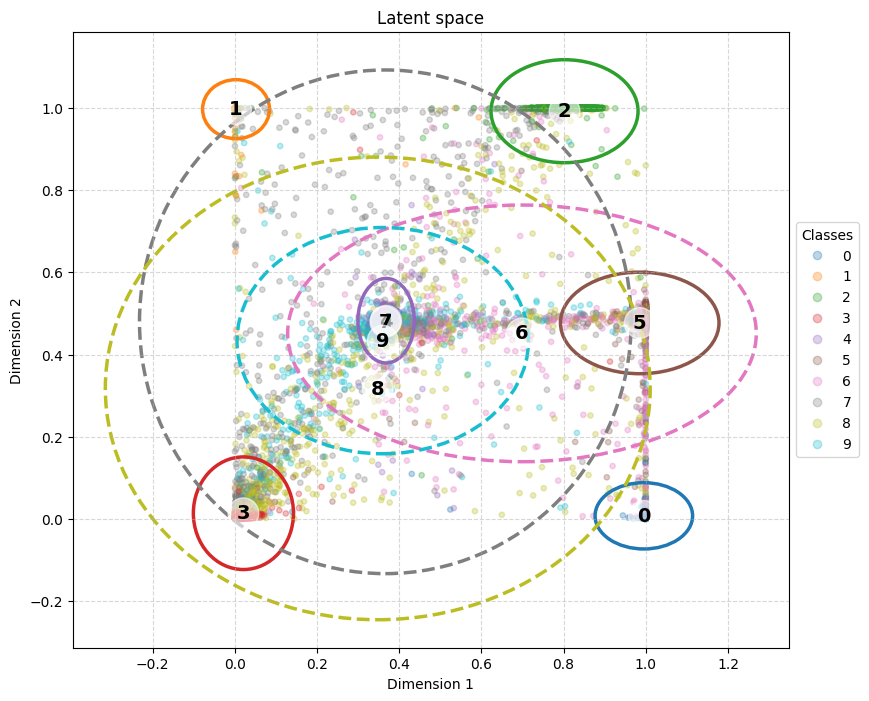

In [14]:
test_loader = DataLoader(test_dataset,
                         batch_size=batch_size,
                         shuffle=False)

encodings_list = []
labels_list = []

with torch.no_grad():
    for x_test, y_test in test_loader:
        _, latent, _ = model(x_test)
        encodings_list.append(latent.cpu())
        labels_list.append(y_test.cpu())

encodings_np = torch.cat(encodings_list).numpy()
labels_np = torch.cat(labels_list).numpy()

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    encodings_np[:, 0],
    encodings_np[:, 1],
    c=labels_np,
    cmap='tab10',
    alpha=0.3,
    s=15
)

ax.set_title('Latent space')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, linestyle='--', alpha=0.5)

for clase in range(10):
    puntos_clase = encodings_np[labels_np == clase]
    if len(puntos_clase) == 0: continue

    media_x, media_y = np.mean(puntos_clase, axis=0)
    std_x, std_y = np.std(puntos_clase, axis=0)
    color = scatter.cmap(scatter.norm(clase))

    elipse = Ellipse(xy=(media_x, media_y),
                     width=std_x * 4,
                     height=std_y * 4,
                     edgecolor=color,
                     fc='None',
                     lw=2.5,
                     linestyle='-' if clase <= 5 else '--')
    ax.add_patch(elipse)
    plt.gca().set_aspect('equal', adjustable='box')

    # Class number.
    ax.annotate(str(clase), (media_x, media_y),
                weight='bold', size=14, ha='center', va='center',
                bbox=dict(boxstyle="circle", alpha=0.6, color='white'))

legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, [str(i) for i in range(10)], title="Classes", loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

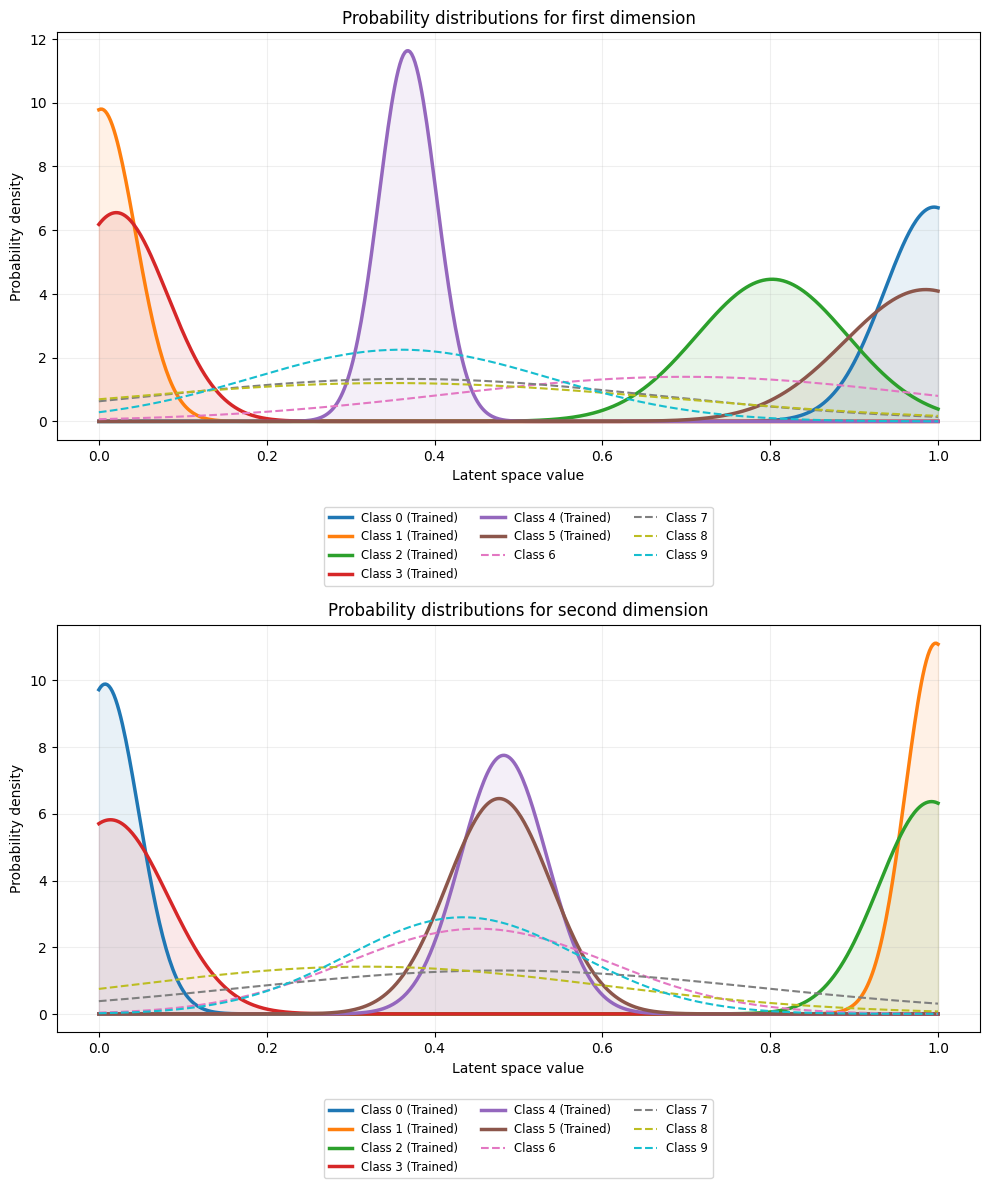

In [15]:
x_range = np.linspace(0, 1, 500)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

for clase in range(10):  # 10 classes.
    estilo = '-' if clase <= 5 else '--'
    ancho = 2.5 if clase <= 5 else 1.5
    alpha_relleno = 0.1 if clase <= 5 else 0.0
    etiqueta = f'Class {clase} (Trained)' if clase <= 5 else f'Class {clase}'

    # Dimension 1.
    datos_d1 = encodings_np[labels_np == clase][:, 0]
    if len(datos_d1) > 0:
        mu1, std1 = np.mean(datos_d1), np.std(datos_d1)
        p_x1 = norm.pdf(x_range, mu1, std1) if std1 > 0 else np.zeros_like(x_range)

        ax1.plot(x_range, p_x1, label=etiqueta, color=colors[clase], lw=ancho, linestyle=estilo)
        if alpha_relleno > 0:
            ax1.fill_between(x_range, p_x1, alpha=alpha_relleno, color=colors[clase])

    # Dimension 2.
    datos_d2 = encodings_np[labels_np == clase][:, 1]
    if len(datos_d2) > 0:
        mu2, std2 = np.mean(datos_d2), np.std(datos_d2)
        p_x2 = norm.pdf(x_range, mu2, std2) if std2 > 0 else np.zeros_like(x_range)

        ax2.plot(x_range, p_x2, label=etiqueta, color=colors[clase], lw=ancho, linestyle=estilo)
        if alpha_relleno > 0:
            ax2.fill_between(x_range, p_x2, alpha=alpha_relleno, color=colors[clase])

for ax, title in zip([ax1, ax2], ['Probability distributions for first dimension', 'Probability distributions for second dimension']):
    ax.set_title(f'{title}')
    ax.set_xlabel('Latent space value')
    ax.set_ylabel('Probability density')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize='small')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.05, 1.05) # Margin for sigmoid edges.

plt.tight_layout()
plt.show()

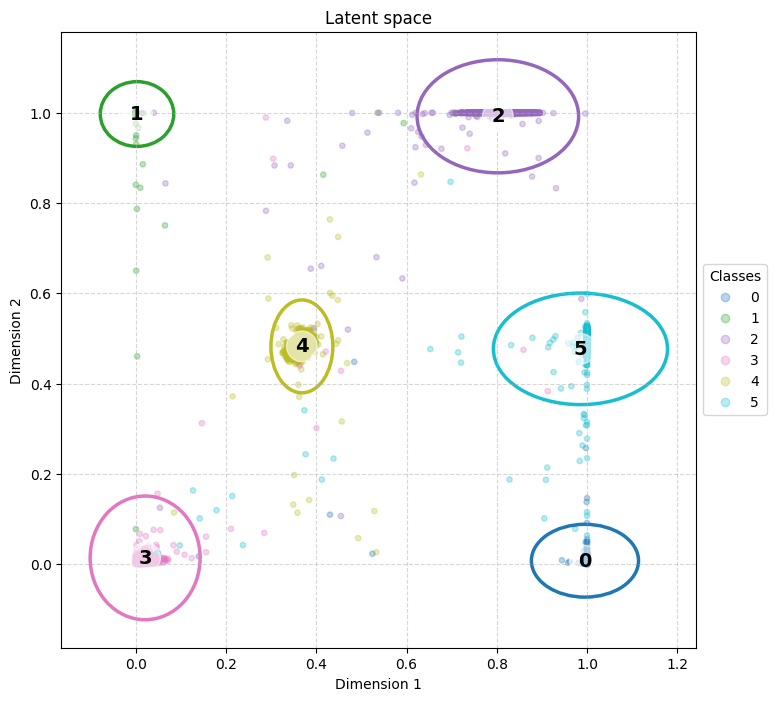

In [16]:
encodings_list = []
labels_list = []
test_dataset_known = filter_dataset(test_dataset, training_labels)
test_loader = DataLoader(test_dataset_known,
                         batch_size=batch_size,
                         shuffle=False)

with torch.no_grad():
    for x_test, y_test in test_loader:
        _, latent, _ = model(x_test)
        encodings_list.append(latent.cpu())
        labels_list.append(y_test.cpu())

encodings_np = torch.cat(encodings_list).numpy()
labels_np = torch.cat(labels_list).numpy()

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    encodings_np[:, 0],
    encodings_np[:, 1],
    c=labels_np,
    cmap='tab10',
    alpha=0.3,
    s=15
)

ax.set_title('Latent space')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, linestyle='--', alpha=0.5)

for clase in range(6):
    puntos_clase = encodings_np[labels_np == clase]
    if len(puntos_clase) == 0: continue

    media_x, media_y = np.mean(puntos_clase, axis=0)
    std_x, std_y = np.std(puntos_clase, axis=0)
    color = scatter.cmap(scatter.norm(clase))

    elipse = Ellipse(xy=(media_x, media_y),
                     width=std_x * 4,
                     height=std_y * 4,
                     edgecolor=color,
                     fc='None',
                     lw=2.5,
                     linestyle='-')
    ax.add_patch(elipse)
    plt.gca().set_aspect('equal', adjustable='box')


    # Class number.
    ax.annotate(str(clase), (media_x, media_y),
                weight='bold', size=14, ha='center', va='center',
                bbox=dict(boxstyle="circle", alpha=0.6, color='white'))

legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, [str(i) for i in range(10)], title="Classes", loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

## Experimento con softmax:

In [17]:
class SoftmaxEncoder(nn.Module):
    def __init__(self, latent_dims=2, num_classes=6):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, latent_dims),
            nn.Softmax(dim = 1)
        )

        self.classifier = nn.Linear(latent_dims, num_classes)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dims, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_space = self.encoder(x)
        predict = self.classifier(latent_space)
        reconstructed = self.decoder(latent_space)
        reconstructed = reconstructed.view(-1, 1, 28, 28)

        return predict, latent_space, reconstructed

Epoch::  26%|██▌       | 510/2000 [03:58<11:36,  2.14it/s, loss=0.3054]


Early Stop en la época 510.


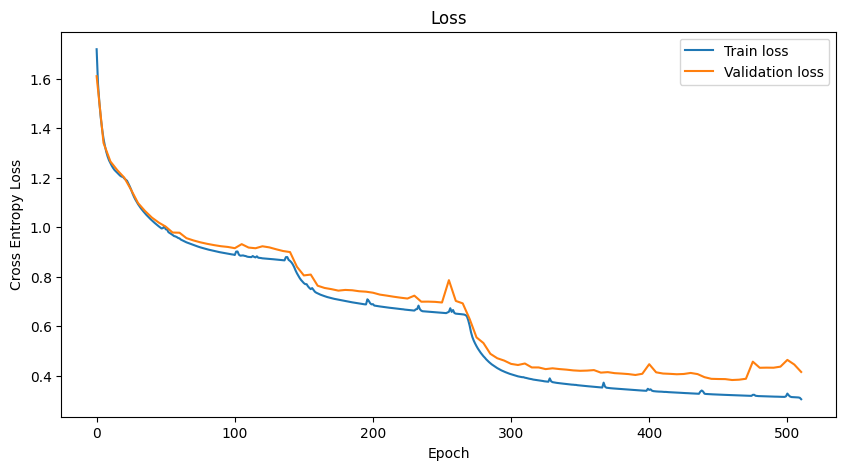

In [18]:
model = SoftmaxEncoder(latent_dims=2).to(device)
learning_rate = 1e-3
early_stop = Early_Stop(patience=patience, delta=delta)
optimizer = torch.optim.Adam

model, train_loss_list, val_loss_list = learning_loop(
    train_loader, val_loader, model, epochs, loss_fn_cls, loss_fn_rec, learning_rate, optimizer, validation_freq, early_stop
)

plt.figure(figsize=(10, 5))
plt.plot(train_loss_list, label='Train loss')
plt.plot(np.arange(0, len(train_loss_list), validation_freq), val_loss_list, label='Validation loss')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.show()

In [19]:
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_step_loss_list = []
test_correct_answers = 0
test_set_size = 0

with torch.no_grad():
    for x_true, y_true in test_loader:

        y_pred, latent_space, x_rec = model(x_true)
        preds = torch.argmax(y_pred, dim=-1)
        correct_answers = torch.sum(preds == y_true)
        test_correct_answers += correct_answers.item()
        test_set_size += y_true.numel()

        mask = y_true <= 5
        if mask.any(): # Si hay al menos un número del 0 al 5 en este batch.
            loss_test_cls = loss_fn_cls(y_pred[mask], y_true[mask])
            loss_test_rec = loss_fn_rec(x_rec[mask], x_true[mask])
            total_loss = loss_test_cls + loss_test_rec
            test_step_loss_list.append(total_loss.item())

final_test_loss = np.mean(test_step_loss_list)
final_test_acc = test_correct_answers / float(test_set_size)

print(f"Test dataset loss (classes 0-5): {final_test_loss:.6f}")
print(f"Test dataset accuracy (classes 0-5): {final_test_acc:.2%}")

Test dataset loss (classes 0-5): 0.440918
Test dataset accuracy (classes 0-5): 55.84%


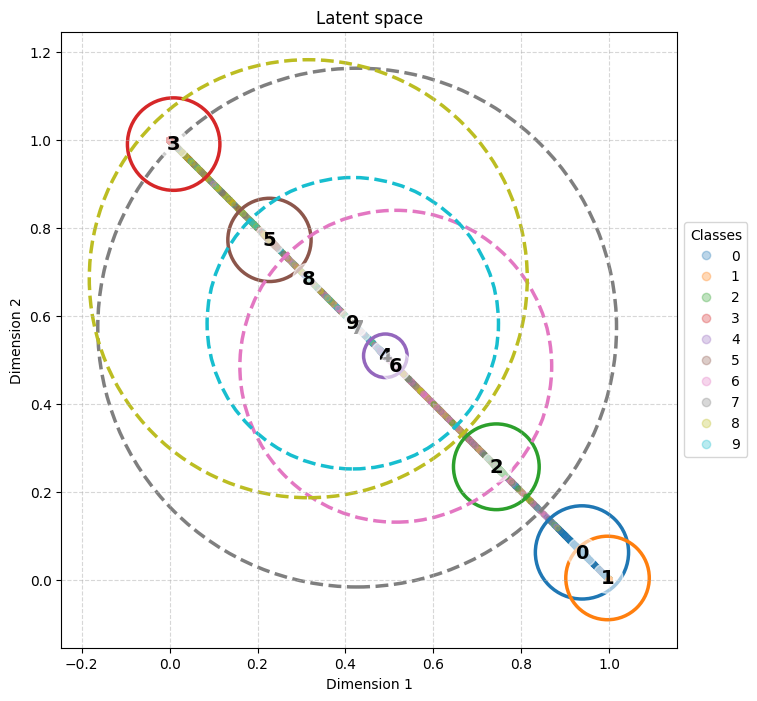

In [20]:
test_loader = DataLoader(test_dataset,
                         batch_size=batch_size,
                         shuffle=False)

encodings_list = []
labels_list = []

with torch.no_grad():
    for x_test, y_test in test_loader:
        _, latent, _ = model(x_test)
        encodings_list.append(latent.cpu())
        labels_list.append(y_test.cpu())

encodings_np = torch.cat(encodings_list).numpy()
labels_np = torch.cat(labels_list).numpy()

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    encodings_np[:, 0],
    encodings_np[:, 1],
    c=labels_np,
    cmap='tab10',
    alpha=0.3,
    s=15
)

ax.set_title('Latent space')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, linestyle='--', alpha=0.5)

for clase in range(10):
    puntos_clase = encodings_np[labels_np == clase]
    if len(puntos_clase) == 0: continue

    media_x, media_y = np.mean(puntos_clase, axis=0)
    std_x, std_y = np.std(puntos_clase, axis=0)
    color = scatter.cmap(scatter.norm(clase))

    elipse = Ellipse(xy=(media_x, media_y),
                     width=std_x * 4,
                     height=std_y * 4,
                     edgecolor=color,
                     fc='None',
                     lw=2.5,
                     linestyle='-' if clase <= 5 else '--')
    ax.add_patch(elipse)
    plt.gca().set_aspect('equal', adjustable='box')


    # Class number.
    ax.annotate(str(clase), (media_x, media_y),
                weight='bold', size=14, ha='center', va='center',
                bbox=dict(boxstyle="circle", alpha=0.6, color='white'))

legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, [str(i) for i in range(10)], title="Classes", loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

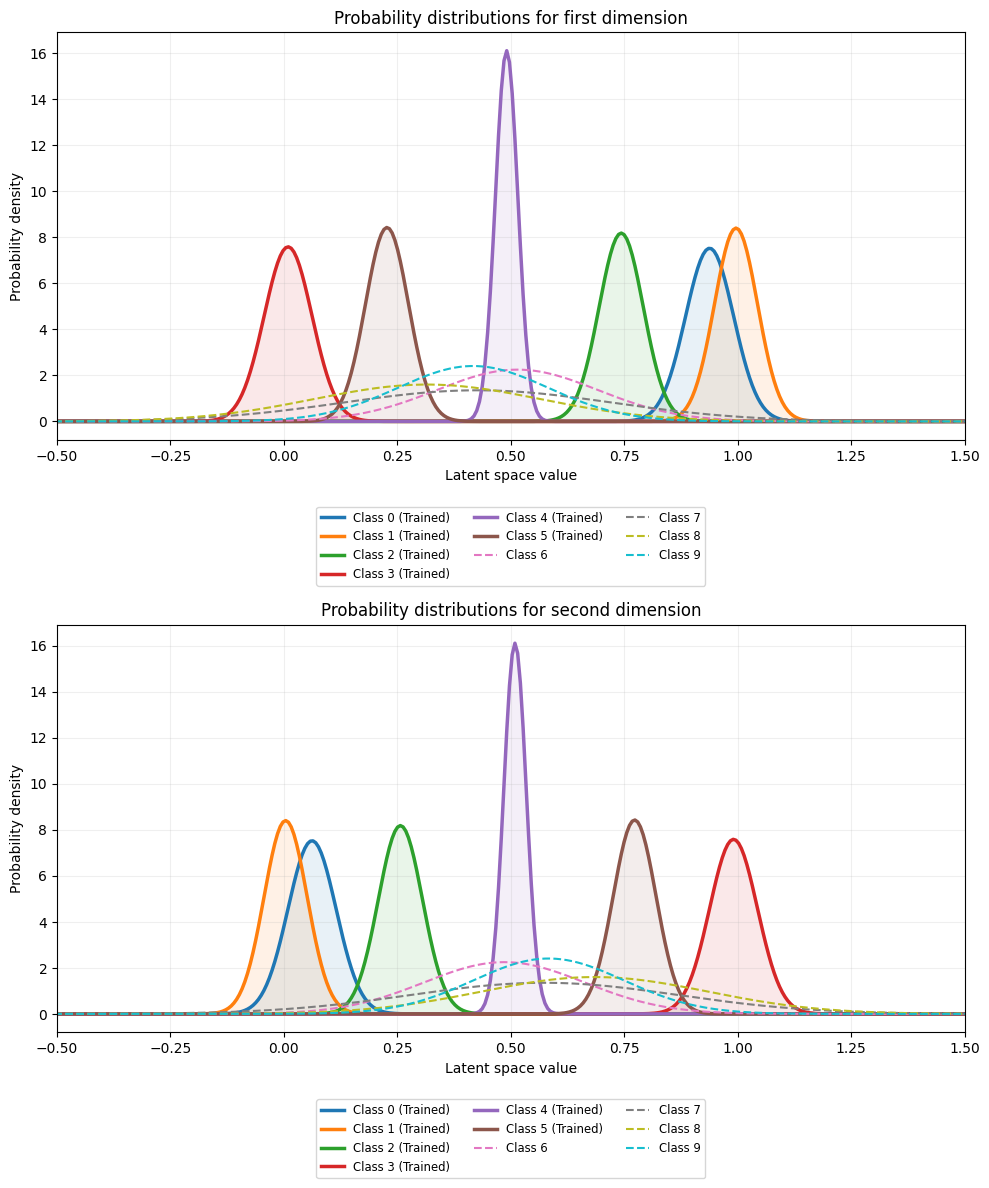

In [21]:
x_min, x_max = encodings_np.min(), encodings_np.max()
x_range = np.linspace(x_min - 1, x_max + 1, 500)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

for clase in range(10):  # 10 classes.
    estilo = '-' if clase <= 5 else '--'
    ancho = 2.5 if clase <= 5 else 1.5
    alpha_relleno = 0.1 if clase <= 5 else 0.0
    etiqueta = f'Class {clase} (Trained)' if clase <= 5 else f'Class {clase}'

    # Dimension 1.
    datos_d1 = encodings_np[labels_np == clase][:, 0]
    if len(datos_d1) > 0:
        mu1, std1 = np.mean(datos_d1), np.std(datos_d1)
        p_x1 = norm.pdf(x_range, mu1, std1) if std1 > 0 else np.zeros_like(x_range)

        ax1.plot(x_range, p_x1, label=etiqueta, color=colors[clase], lw=ancho, linestyle=estilo)
        if alpha_relleno > 0:
            ax1.fill_between(x_range, p_x1, alpha=alpha_relleno, color=colors[clase])

    # Dimension 2.
    datos_d2 = encodings_np[labels_np == clase][:, 1]
    if len(datos_d2) > 0:
        mu2, std2 = np.mean(datos_d2), np.std(datos_d2)
        p_x2 = norm.pdf(x_range, mu2, std2) if std2 > 0 else np.zeros_like(x_range)

        ax2.plot(x_range, p_x2, label=etiqueta, color=colors[clase], lw=ancho, linestyle=estilo)
        if alpha_relleno > 0:
            ax2.fill_between(x_range, p_x2, alpha=alpha_relleno, color=colors[clase])

for ax, title in zip([ax1, ax2], ['Probability distributions for first dimension', 'Probability distributions for second dimension']):
    ax.set_title(f'{title}')
    ax.set_xlabel('Latent space value')
    ax.set_ylabel('Probability density')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize='small')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(x_min - 0.5, x_max + 0.5)

plt.tight_layout()
plt.show()

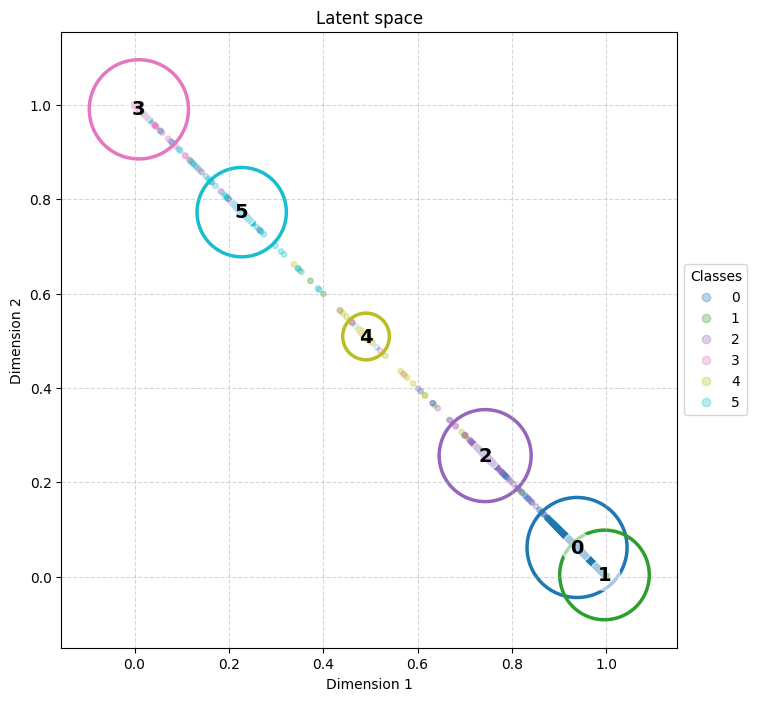

In [22]:
encodings_list = []
labels_list = []
test_dataset_known = filter_dataset(test_dataset, training_labels)
test_loader = DataLoader(test_dataset_known,
                         batch_size=batch_size,
                         shuffle=False)

with torch.no_grad():
    for x_test, y_test in test_loader:
        _, latent, _ = model(x_test)
        encodings_list.append(latent.cpu())
        labels_list.append(y_test.cpu())

encodings_np = torch.cat(encodings_list).numpy()
labels_np = torch.cat(labels_list).numpy()

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    encodings_np[:, 0],
    encodings_np[:, 1],
    c=labels_np,
    cmap='tab10',
    alpha=0.3,
    s=15
)

ax.set_title('Latent space')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, linestyle='--', alpha=0.5)

for clase in range(6):
    puntos_clase = encodings_np[labels_np == clase]
    if len(puntos_clase) == 0: continue

    media_x, media_y = np.mean(puntos_clase, axis=0)
    std_x, std_y = np.std(puntos_clase, axis=0)
    color = scatter.cmap(scatter.norm(clase))

    elipse = Ellipse(xy=(media_x, media_y),
                     width=std_x * 4,
                     height=std_y * 4,
                     edgecolor=color,
                     fc='None',
                     lw=2.5,
                     linestyle='-')
    ax.add_patch(elipse)
    plt.gca().set_aspect('equal', adjustable='box')


    # Class number.
    ax.annotate(str(clase), (media_x, media_y),
                weight='bold', size=14, ha='center', va='center',
                bbox=dict(boxstyle="circle", alpha=0.6, color='white'))

legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, [str(i) for i in range(10)], title="Classes", loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

## Experimento con espacio latente sin restricción:

In [23]:
class FreeEncoder(nn.Module):
    def __init__(self, latent_dims=2, num_classes=6):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, latent_dims)
        )

        self.classifier = nn.Linear(latent_dims, num_classes)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dims, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_space = self.encoder(x)
        predict = self.classifier(latent_space)
        reconstructed = self.decoder(latent_space)
        reconstructed = reconstructed.view(-1, 1, 28, 28)

        return predict, latent_space, reconstructed

Epoch::   3%|▎         | 65/2000 [00:29<14:49,  2.17it/s, loss=0.0401]


Early Stop en la época 65.


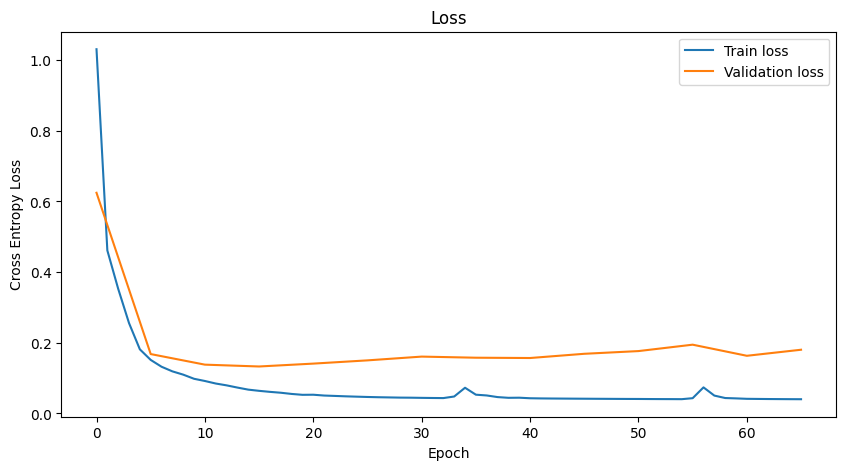

In [24]:
model = FreeEncoder(latent_dims=2).to(device)
learning_rate = 1e-3
early_stop = Early_Stop(patience=patience, delta=delta)
optimizer = torch.optim.Adam

model, train_loss_list, val_loss_list = learning_loop(
    train_loader, val_loader, model, epochs, loss_fn_cls, loss_fn_rec, learning_rate, optimizer, validation_freq, early_stop
)

plt.figure(figsize=(10, 5))
plt.plot(train_loss_list, label='Train loss')
plt.plot(np.arange(0, len(train_loss_list), validation_freq), val_loss_list, label='Validation loss')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.show()

In [25]:
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_step_loss_list = []
test_correct_answers = 0
test_set_size = 0

with torch.no_grad():
    for x_true, y_true in test_loader:

        y_pred, latent_space, x_rec = model(x_true)
        preds = torch.argmax(y_pred, dim=-1)
        correct_answers = torch.sum(preds == y_true)
        test_correct_answers += correct_answers.item()
        test_set_size += y_true.numel()

        mask = y_true <= 5
        if mask.any(): # Si hay al menos un número del 0 al 5 en este batch.
            loss_test_cls = loss_fn_cls(y_pred[mask], y_true[mask])
            loss_test_rec = loss_fn_rec(x_rec[mask], x_true[mask])
            total_loss = loss_test_cls + loss_test_rec
            test_step_loss_list.append(total_loss.item())

final_test_loss = np.mean(test_step_loss_list)
final_test_acc = test_correct_answers / float(test_set_size)

print(f"Test dataset loss (classes 0-5): {final_test_loss:.6f}")
print(f"Test dataset accuracy (classes 0-5): {final_test_acc:.2%}")

Test dataset loss (classes 0-5): 0.188232
Test dataset accuracy (classes 0-5): 59.30%


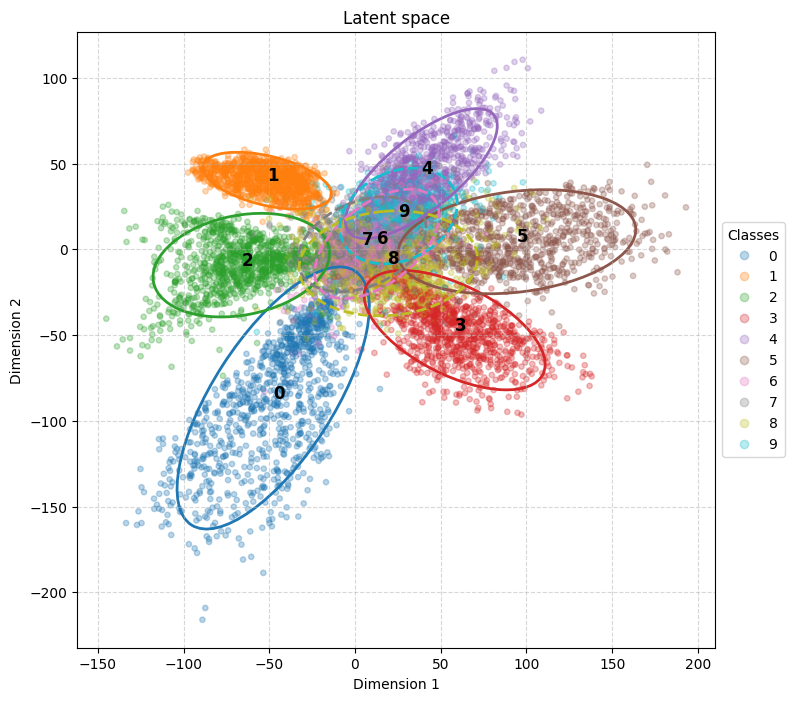

In [26]:
test_loader = DataLoader(test_dataset,
                         batch_size=batch_size,
                         shuffle=False)

encodings_list = []
labels_list = []

with torch.no_grad():
    for x_test, y_test in test_loader:
        _, latent, _ = model(x_test)
        encodings_list.append(latent.cpu())
        labels_list.append(y_test.cpu())

encodings_np = torch.cat(encodings_list).numpy()
labels_np = torch.cat(labels_list).numpy()

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    encodings_np[:, 0],
    encodings_np[:, 1],
    c=labels_np,
    cmap='tab10',
    alpha=0.3,
    s=15
)

ax.set_title('Latent space')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, linestyle='--', alpha=0.5)

for clase in range(10):
    puntos_clase = encodings_np[labels_np == clase]
    if len(puntos_clase) > 1: # Necesito al menos dos puntos para calcular la covarianza

        color = plt.cm.tab10(clase / 10.0)

        ellipse = covariance_ellipse(
            puntos_clase,
            num_of_stds=2.0,
            edgecolor=color,
            facecolor='none',
            linewidth=2,
            linestyle='-' if clase <= 5 else '--'
        )

        ax.add_patch(ellipse)
        plt.gca().set_aspect('equal', adjustable='box')

        center = np.mean(puntos_clase, axis=0)
        ax.text(center[0], center[1], str(clase), fontsize=12, weight='bold', color='black')

legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, [str(i) for i in range(10)], title="Classes", loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

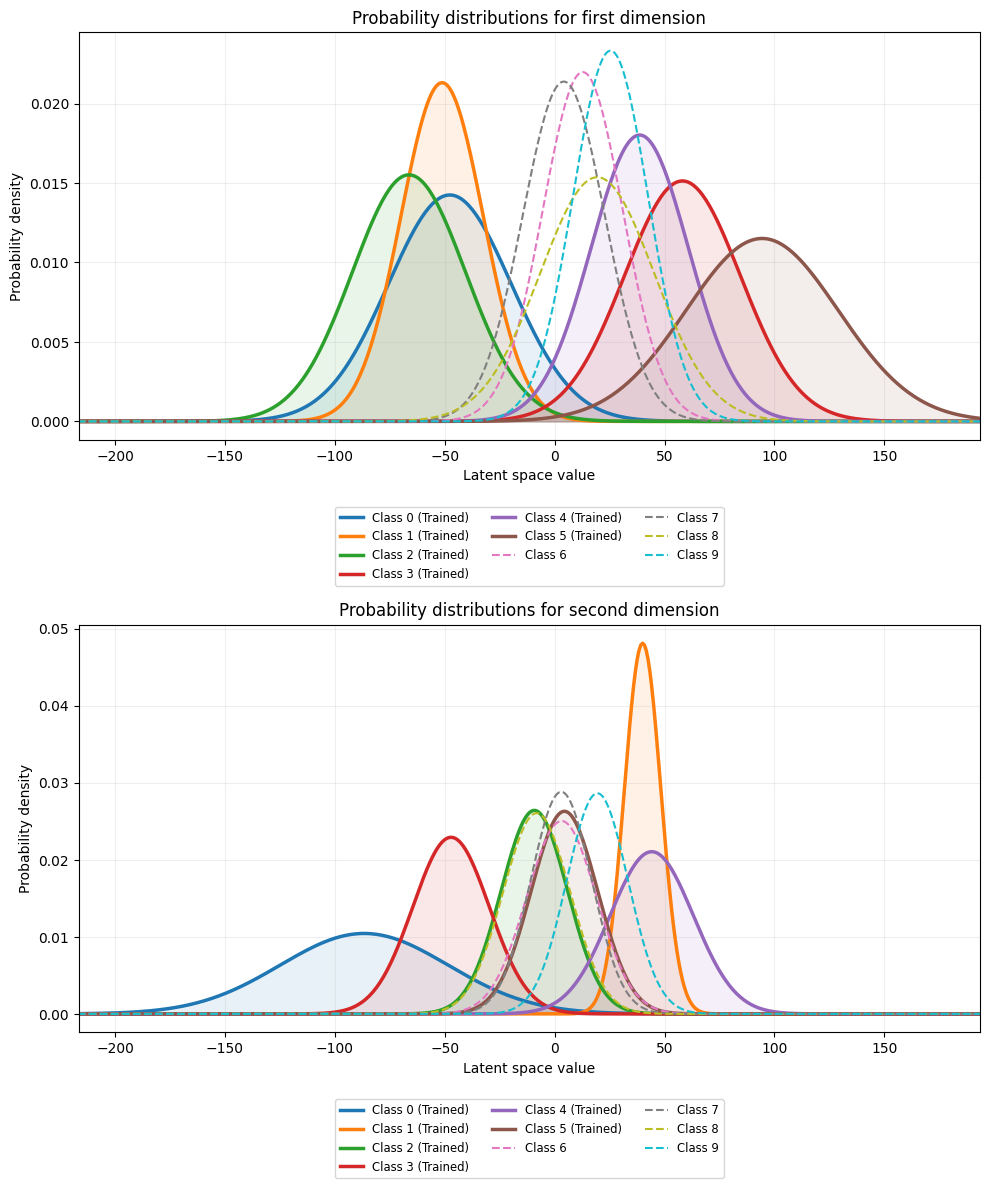

In [27]:
x_min, x_max = encodings_np.min(), encodings_np.max()
x_range = np.linspace(x_min - 1, x_max + 1, 500)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

for clase in range(10):  # 10 classes.
    estilo = '-' if clase <= 5 else '--'
    ancho = 2.5 if clase <= 5 else 1.5
    alpha_relleno = 0.1 if clase <= 5 else 0.0
    etiqueta = f'Class {clase} (Trained)' if clase <= 5 else f'Class {clase}'

    # Dimension 1.
    datos_d1 = encodings_np[labels_np == clase][:, 0]
    if len(datos_d1) > 0:
        mu1, std1 = np.mean(datos_d1), np.std(datos_d1)
        p_x1 = norm.pdf(x_range, mu1, std1) if std1 > 0 else np.zeros_like(x_range)

        ax1.plot(x_range, p_x1, label=etiqueta, color=colors[clase], lw=ancho, linestyle=estilo)
        if alpha_relleno > 0:
            ax1.fill_between(x_range, p_x1, alpha=alpha_relleno, color=colors[clase])

    # Dimension 2.
    datos_d2 = encodings_np[labels_np == clase][:, 1]
    if len(datos_d2) > 0:
        mu2, std2 = np.mean(datos_d2), np.std(datos_d2)
        p_x2 = norm.pdf(x_range, mu2, std2) if std2 > 0 else np.zeros_like(x_range)

        ax2.plot(x_range, p_x2, label=etiqueta, color=colors[clase], lw=ancho, linestyle=estilo)
        if alpha_relleno > 0:
            ax2.fill_between(x_range, p_x2, alpha=alpha_relleno, color=colors[clase])

for ax, title in zip([ax1, ax2], ['Probability distributions for first dimension', 'Probability distributions for second dimension']):
    ax.set_title(f'{title}')
    ax.set_xlabel('Latent space value')
    ax.set_ylabel('Probability density')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize='small')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(x_min - 0.5, x_max + 0.5)

plt.tight_layout()
plt.show()

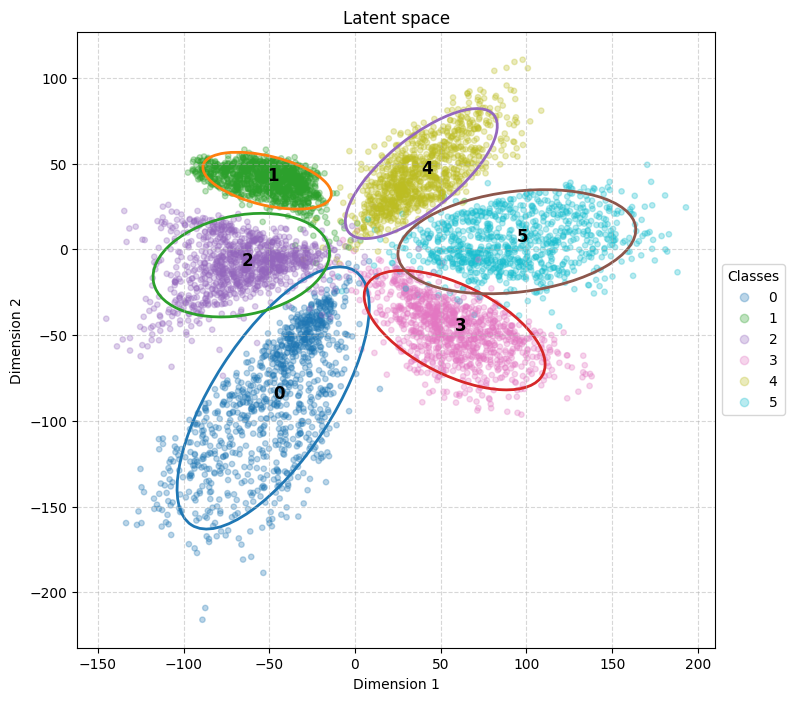

In [28]:
encodings_list = []
labels_list = []
test_dataset_known = filter_dataset(test_dataset, training_labels)
test_loader = DataLoader(test_dataset_known,
                         batch_size=batch_size,
                         shuffle=False)

with torch.no_grad():
    for x_test, y_test in test_loader:
        _, latent, _ = model(x_test)
        encodings_list.append(latent.cpu())
        labels_list.append(y_test.cpu())

encodings_np = torch.cat(encodings_list).numpy()
labels_np = torch.cat(labels_list).numpy()

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    encodings_np[:, 0],
    encodings_np[:, 1],
    c=labels_np,
    cmap='tab10',
    alpha=0.3,
    s=15
)

ax.set_title('Latent space')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, linestyle='--', alpha=0.5)

for clase in range(6):
    puntos_clase = encodings_np[labels_np == clase]
    if len(puntos_clase) > 1:

        color = plt.cm.tab10(clase / 10.0)

        ellipse = covariance_ellipse(
            puntos_clase,
            num_of_stds=2.0,
            edgecolor=color,
            facecolor='none',
            linewidth=2,
            linestyle='-' if clase <= 5 else '--'
        )

        ax.add_patch(ellipse)
        plt.gca().set_aspect('equal', adjustable='box')

        center = np.mean(puntos_clase, axis=0)
        ax.text(center[0], center[1], str(clase), fontsize=12, weight='bold', color='black')

legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, [str(i) for i in range(10)], title="Classes", loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

## Experimento con LeakyReLU

In [29]:
class LeakyEncoder(nn.Module):
    def __init__(self, latent_dims=2, num_classes=6):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, latent_dims),
            nn.LeakyReLU()
        )

        self.classifier = nn.Linear(latent_dims, num_classes)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dims, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_space = self.encoder(x)
        predict = self.classifier(latent_space)
        reconstructed = self.decoder(latent_space)
        reconstructed = reconstructed.view(-1, 1, 28, 28)

        return predict, latent_space, reconstructed

Epoch::   6%|▌         | 110/2000 [00:51<14:44,  2.14it/s, loss=0.0483]


Early Stop en la época 110.


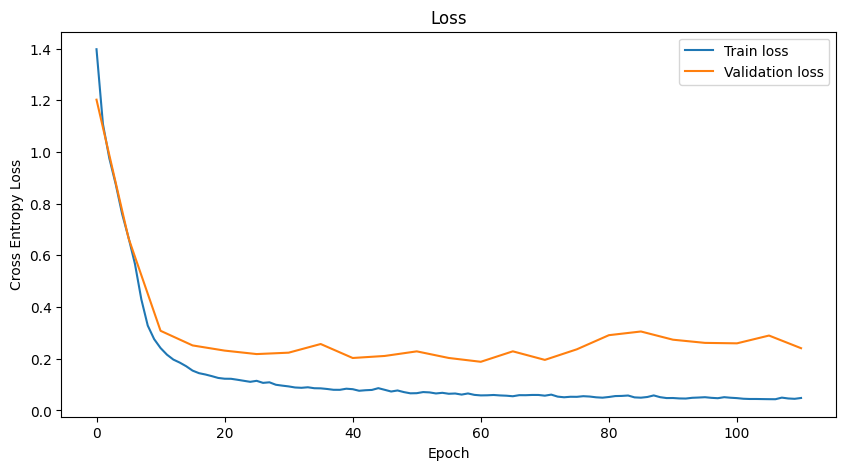

In [30]:
model = LeakyEncoder(latent_dims=2).to(device)
learning_rate = 1e-3
early_stop = Early_Stop(patience=patience, delta=delta)
optimizer = torch.optim.Adam

model, train_loss_list, val_loss_list = learning_loop(
    train_loader, val_loader, model, epochs, loss_fn_cls, loss_fn_rec, learning_rate, optimizer, validation_freq, early_stop
)

plt.figure(figsize=(10, 5))
plt.plot(train_loss_list, label='Train loss')
plt.plot(np.arange(0, len(train_loss_list), validation_freq), val_loss_list, label='Validation loss')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.show()

In [31]:
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_step_loss_list = []
test_correct_answers = 0
test_set_size = 0

with torch.no_grad():
    for x_true, y_true in test_loader:

        y_pred, latent_space, x_rec = model(x_true)
        preds = torch.argmax(y_pred, dim=-1)
        correct_answers = torch.sum(preds == y_true)
        test_correct_answers += correct_answers.item()
        test_set_size += y_true.numel()

        mask = y_true <= 5
        if mask.any(): # Si hay al menos un número del 0 al 5 en este batch.
            loss_test_cls = loss_fn_cls(y_pred[mask], y_true[mask])
            loss_test_rec = loss_fn_rec(x_rec[mask], x_true[mask])
            total_loss = loss_test_cls + loss_test_rec
            test_step_loss_list.append(total_loss.item())

final_test_loss = np.mean(test_step_loss_list)
final_test_acc = test_correct_answers / float(test_set_size)

print(f"Test dataset loss (classes 0-5): {final_test_loss:.6f}")
print(f"Test dataset accuracy (classes 0-5): {final_test_acc:.2%}")

Test dataset loss (classes 0-5): 0.203451
Test dataset accuracy (classes 0-5): 59.20%


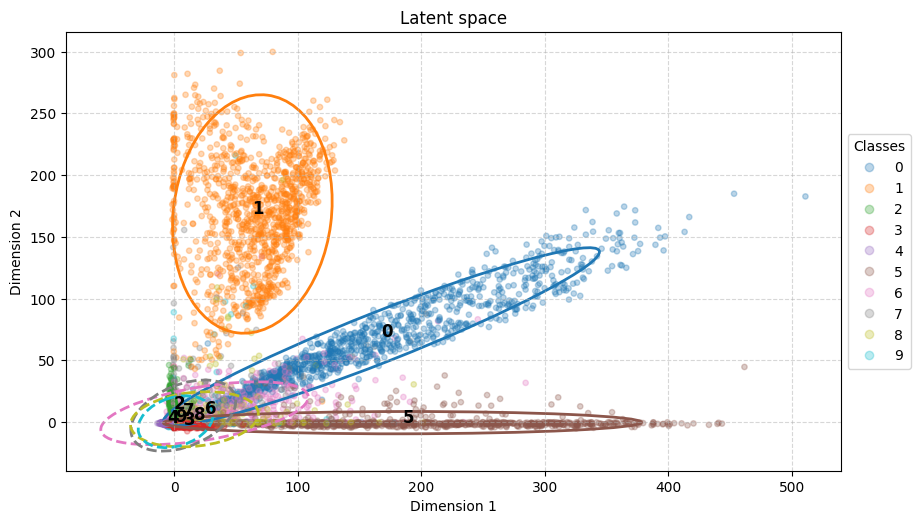

In [32]:
test_loader = DataLoader(test_dataset,
                         batch_size=batch_size,
                         shuffle=False)

encodings_list = []
labels_list = []

with torch.no_grad():
    for x_test, y_test in test_loader:
        _, latent, _ = model(x_test)
        encodings_list.append(latent.cpu())
        labels_list.append(y_test.cpu())

encodings_np = torch.cat(encodings_list).numpy()
labels_np = torch.cat(labels_list).numpy()

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    encodings_np[:, 0],
    encodings_np[:, 1],
    c=labels_np,
    cmap='tab10',
    alpha=0.3,
    s=15
)

ax.set_title('Latent space')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, linestyle='--', alpha=0.5)

for clase in range(10):
    puntos_clase = encodings_np[labels_np == clase]
    if len(puntos_clase) > 1: # Al menos dos puntos para calcular la covarianza.

        color = plt.cm.tab10(clase / 10.0)

        ellipse = covariance_ellipse(
            puntos_clase,
            num_of_stds=2.0,
            edgecolor=color,
            facecolor='none',
            linewidth=2,
            linestyle='-' if clase <= 5 else '--'
        )

        ax.add_patch(ellipse)
        plt.gca().set_aspect('equal', adjustable='box')

        center = np.mean(puntos_clase, axis=0)
        ax.text(center[0], center[1], str(clase), fontsize=12, weight='bold', color='black')

legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, [str(i) for i in range(10)], title="Classes", loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

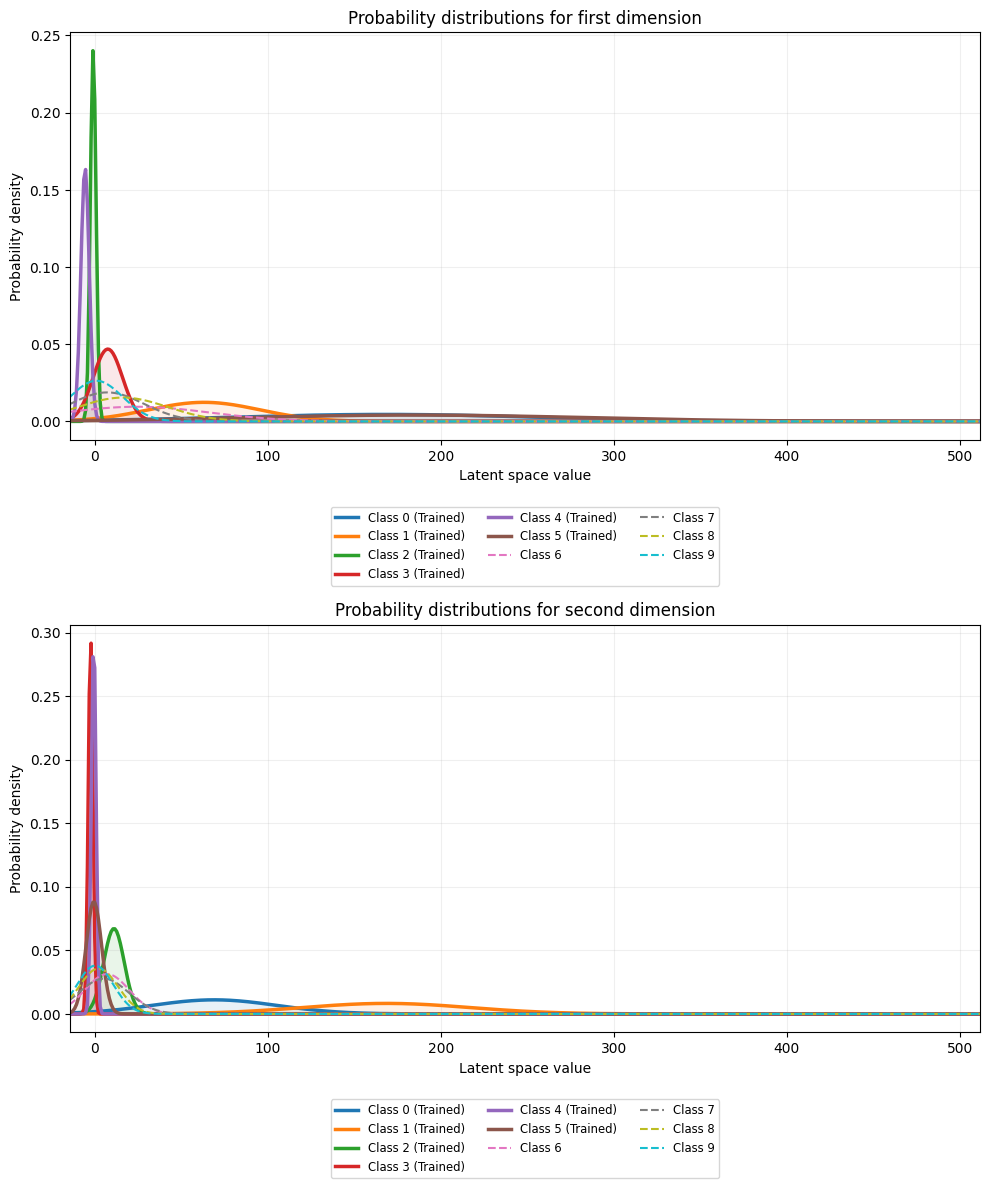

In [33]:
x_min, x_max = encodings_np.min(), encodings_np.max()
x_range = np.linspace(x_min - 1, x_max + 1, 500)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

for clase in range(10):  # 10 classes.
    estilo = '-' if clase <= 5 else '--'
    ancho = 2.5 if clase <= 5 else 1.5
    alpha_relleno = 0.1 if clase <= 5 else 0.0
    etiqueta = f'Class {clase} (Trained)' if clase <= 5 else f'Class {clase}'

    # Dimension 1.
    datos_d1 = encodings_np[labels_np == clase][:, 0]
    if len(datos_d1) > 0:
        mu1, std1 = np.mean(datos_d1), np.std(datos_d1)
        p_x1 = norm.pdf(x_range, mu1, std1) if std1 > 0 else np.zeros_like(x_range)

        ax1.plot(x_range, p_x1, label=etiqueta, color=colors[clase], lw=ancho, linestyle=estilo)
        if alpha_relleno > 0:
            ax1.fill_between(x_range, p_x1, alpha=alpha_relleno, color=colors[clase])

    # Dimension 2.
    datos_d2 = encodings_np[labels_np == clase][:, 1]
    if len(datos_d2) > 0:
        mu2, std2 = np.mean(datos_d2), np.std(datos_d2)
        p_x2 = norm.pdf(x_range, mu2, std2) if std2 > 0 else np.zeros_like(x_range)

        ax2.plot(x_range, p_x2, label=etiqueta, color=colors[clase], lw=ancho, linestyle=estilo)
        if alpha_relleno > 0:
            ax2.fill_between(x_range, p_x2, alpha=alpha_relleno, color=colors[clase])

for ax, title in zip([ax1, ax2], ['Probability distributions for first dimension', 'Probability distributions for second dimension']):
    ax.set_title(f'{title}')
    ax.set_xlabel('Latent space value')
    ax.set_ylabel('Probability density')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize='small')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(x_min - 0.5, x_max + 0.5)

plt.tight_layout()
plt.show()

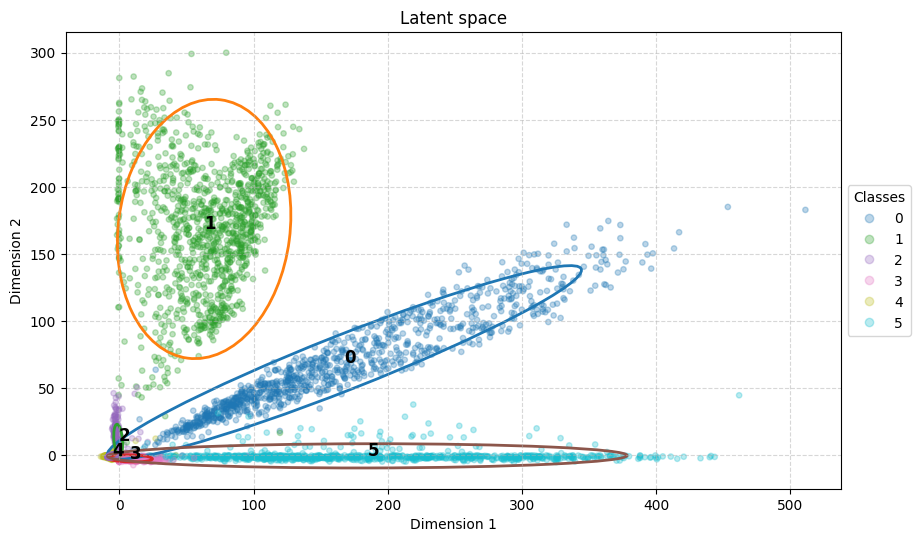

In [34]:
encodings_list = []
labels_list = []
test_dataset_known = filter_dataset(test_dataset, training_labels)
test_loader = DataLoader(test_dataset_known,
                         batch_size=batch_size,
                         shuffle=False)

with torch.no_grad():
    for x_test, y_test in test_loader:
        _, latent, _ = model(x_test)
        encodings_list.append(latent.cpu())
        labels_list.append(y_test.cpu())

encodings_np = torch.cat(encodings_list).numpy()
labels_np = torch.cat(labels_list).numpy()

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    encodings_np[:, 0],
    encodings_np[:, 1],
    c=labels_np,
    cmap='tab10',
    alpha=0.3,
    s=15
)

ax.set_title('Latent space')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, linestyle='--', alpha=0.5)

for clase in range(6):
    puntos_clase = encodings_np[labels_np == clase]
    if len(puntos_clase) > 1:

        color = plt.cm.tab10(clase / 10.0)

        ellipse = covariance_ellipse(
            puntos_clase,
            num_of_stds=2.0,
            edgecolor=color,
            facecolor='none',
            linewidth=2,
            linestyle='-' if clase <= 5 else '--'
        )

        ax.add_patch(ellipse)
        plt.gca().set_aspect('equal', adjustable='box')
        center = np.mean(puntos_clase, axis=0)
        ax.text(center[0], center[1], str(clase), fontsize=12, weight='bold', color='black')

legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, [str(i) for i in range(10)], title="Classes", loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()